# Aufgabe 4e: Gemeinsamer Klassifikationsvergleich

Dieses Notebook trainiert keine Modelle. Es lädt ausschließlich die vollständigen Spendervorhersagen von CellCNN, Citrus und der linearen Single-Cell-SVM, prüft deren Vergleichbarkeit und berechnet alle Metriken mit derselben Implementierung.

## 1. Konfiguration und Ergebnisdateien

In [1]:
# Zweck: Vollständige Aufgabe-4-Artefakte finden und gemeinsame Vergleichsparameter festlegen.
from pathlib import Path
import warnings

import flowkit as fk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    auc, average_precision_score, balanced_accuracy_score, precision_recall_curve, roc_auc_score
)

GATE = "gated_alive"
RUN_MODE = "full"
EXPECTED_SPLIT_COUNT = 100

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "NK_cell_dataset").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
SPLITS_PATH = TABLES_DIR / "task4_donor_splits.csv"
PREDICTION_PATHS = {
    "CellCNN": TABLES_DIR / "task4_cellcnn_predictions_gated_alive_full.csv",
    "Citrus": TABLES_DIR / "task4_citrus_predictions_gated_alive_full.csv",
    "Lineare Single-Cell-SVM": (
        TABLES_DIR / "task4_svm_predictions_gated_alive_full.csv"
    ),
}
EXPECTED_METHOD_VALUES = {
    "CellCNN": "cellcnn",
    "Citrus": "citrus",
    "Lineare Single-Cell-SVM": "linear_single_cell_svm",
}

missing_paths = [path for path in [SPLITS_PATH, *PREDICTION_PATHS.values()] if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Vollständige Eingabedateien fehlen:\n"
        + "\n".join(f"- {path}" for path in missing_paths)
    )

## 2. Vergleichbarkeit der Vorhersagen prüfen

Für diesen Vergleich wurden alle drei Methoden mit der aktuellen Implementierung
auf `gated_alive` vollständig neu berechnet. Für jede Methode liegen die
Vorhersagen und der Konfigurationsnachweis vor; SVM und CellCNN enthalten auch
die vollständigen Modellparameter für Aufgabe 5.

Jede Methode muss für dieselben 100 Splits genau die sechs äußeren Testspender enthalten. Labels, Gate und Split-Seeds müssen mit der zentralen Splitdatei übereinstimmen.

In [2]:
# Zweck: Vor jeder Metrik beweisen, dass alle Methoden dieselben Testspender bewertet haben.
donor_splits = pd.read_csv(SPLITS_PATH)
expected_test = donor_splits.loc[
    donor_splits["outer_partition"].eq("test"),
    ["split_id", "split_seed", "donor_id", "label"],
].rename(columns={"label": "y_true"})
assert expected_test["split_id"].nunique() == EXPECTED_SPLIT_COUNT
assert expected_test.groupby("split_id").size().eq(6).all()

prediction_tables = []
for method_label, path in PREDICTION_PATHS.items():
    table = pd.read_csv(path)
    required_columns = {
        "gate", "run_mode", "split_id", "split_seed",
        "donor_id", "y_true", "score", "decision_threshold", "y_pred",
    }
    missing_columns = required_columns - set(table.columns)
    if missing_columns:
        raise ValueError(f"{method_label}: fehlende Spalten {missing_columns}")
    assert table["gate"].eq(GATE).all()
    assert table["run_mode"].eq(RUN_MODE).all()
    assert table["method"].eq(EXPECTED_METHOD_VALUES[method_label]).all()
    assert table["split_id"].nunique() == EXPECTED_SPLIT_COUNT
    assert table.groupby("split_id").size().eq(6).all()
    assert table.groupby(["split_id", "donor_id"]).size().eq(1).all()
    assert np.isfinite(table["score"]).all()
    assert np.isfinite(table["decision_threshold"]).all()
    assert set(table["y_pred"]).issubset({0, 1})
    assert table["y_pred"].eq(
        table["score"].ge(table["decision_threshold"]).astype(int)
    ).all()
    # Der Eins-zu-eins-Merge deckt vertauschte Labels, Seeds oder Spender sofort auf.
    observed = table[["split_id", "split_seed", "donor_id", "y_true"]]
    assert observed.merge(
        expected_test,
        on=["split_id", "split_seed", "donor_id", "y_true"],
        validate="one_to_one",
    ).shape[0] == len(observed) == len(expected_test)
    table = table.copy()
    table["method_label"] = method_label
    prediction_tables.append(table)

predictions = pd.concat(prediction_tables, ignore_index=True)
comparison_overview = (
    predictions.groupby("method_label")
    .agg(splits=("split_id", "nunique"), predictions=("score", "size"))
)
display(comparison_overview)

,splits,predictions
method_label,,
CellCNN,100,600
Citrus,100,600
Lineare Single-Cell-SVM,100,600


## 3. Einheitliche spenderbezogene Metriken

ROC-AUC bleibt die Hauptmetrik. Ergänzend berichten wir Average Precision (AP)
und Balanced Accuracy. Die bisherige trapezoidale PR-AUC bleibt unter `pr_auc`
erhalten; `average_precision` ist eine zusätzliche, anders definierte Metrik.

AP gewichtet Precision mit den Recall-Zuwächsen, ohne die PR-Kurve linear zu
interpolieren. Bei zwei CMV+- und vier CMV−-Testspendern liefert ein konstanter
Score AP = 1/3, aber trapezoidale PR-AUC = 2/3. Letztere darf deshalb nicht mit
dem positiven Anteil als Zufallsreferenz oder mit AP gleichgesetzt werden.
[Definitionen in scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

Ein Split enthält nur sechs Testspender. Die Verteilungen über die identischen
Wiederholungen beschreiben die Abhängigkeit von der Aufteilung dieser Kohorte.


In [3]:
# Zweck: Alle Methoden mit derselben spenderbezogenen Metrikimplementierung auswerten.
def trapezoidal_pr_auc(y_true, scores):
    """Die Fläche unter der Precision-Recall-Kurve trapezoidal integrieren."""
    precision, recall, _ = precision_recall_curve(y_true, scores)
    return float(auc(recall, precision))

def compute_metrics(group):
    """ROC-AUC, AP, trapezoidale PR-AUC und Balanced Accuracy liefern."""
    return pd.Series(
        {
            "roc_auc": roc_auc_score(group["y_true"], group["score"]),
            "average_precision": average_precision_score(group["y_true"], group["score"]),
            "pr_auc": trapezoidal_pr_auc(group["y_true"], group["score"]),
            "balanced_accuracy": balanced_accuracy_score(
                group["y_true"], group["y_pred"]
            ),
        }
    )

split_metrics = (
    predictions.groupby(["method_label", "split_id"])
    .apply(compute_metrics, include_groups=False)
    .reset_index()
)
metric_columns = ["roc_auc", "average_precision", "pr_auc", "balanced_accuracy"]
# Verteilungen über Splits werden zusammengefasst, nicht 600 Zeilen als unabhängig behandelt.
summary_records = []
for method_label, group in split_metrics.groupby("method_label"):
    for metric in metric_columns:
        summary_records.append(
            {
                "Methode": method_label,
                "Metrik": metric,
                "Median": group[metric].median(),
                "Q1": group[metric].quantile(0.25),
                "Q3": group[metric].quantile(0.75),
                "Mittelwert": group[metric].mean(),
                "Standardabweichung": group[metric].std(),
            }
        )
metric_summary = pd.DataFrame(summary_records)
split_metrics.to_csv(TABLES_DIR / "task4_split_metrics.csv", index=False)
metric_summary.to_csv(TABLES_DIR / "task4_metric_summary.csv", index=False)
display(metric_summary.round(3))

,Methode,Metrik,Median,Q1,Q3,Mittelwert,Standardabweichung
0,CellCNN,roc_auc,0.875,0.750,1.000,0.808,0.193
1,CellCNN,average_precision,0.833,0.700,1.000,0.804,0.180
2,CellCNN,pr_auc,0.792,0.662,1.000,0.761,0.224
3,CellCNN,balanced_accuracy,0.750,0.500,0.781,0.679,0.190
4,Citrus,roc_auc,0.625,0.500,0.750,0.588,0.210
5,Citrus,average_precision,0.500,0.333,0.675,0.535,0.191
6,Citrus,pr_auc,0.417,0.291,0.667,0.492,0.223
7,Citrus,balanced_accuracy,0.500,0.500,0.625,0.544,0.169
8,Lineare Single-Cell-SVM,roc_auc,0.875,0.625,1.000,0.784,0.195
9,Lineare Single-Cell-SVM,average_precision,0.833,0.692,1.000,0.780,0.182


## 4. ROC-AUC über identische Splits

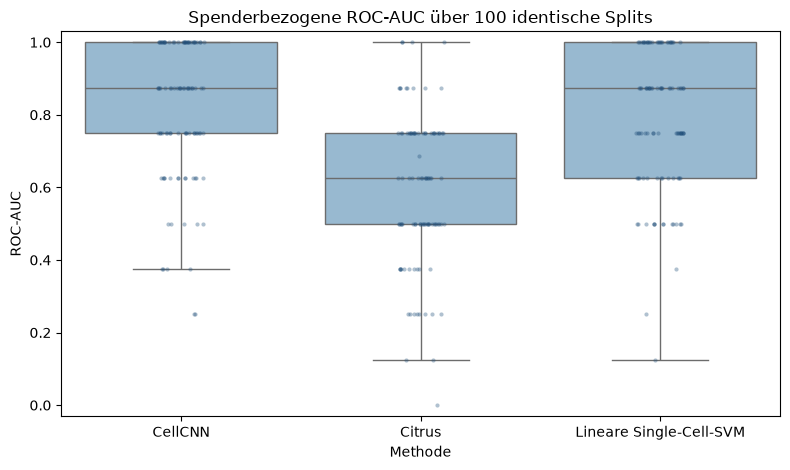

In [4]:
# Zweck: Verteilung aller Split-ROC-AUCs in einer berichtstauglichen Abbildung zeigen.
method_order = ["CellCNN", "Citrus", "Lineare Single-Cell-SVM"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.boxplot(
    data=split_metrics, x="method_label", y="roc_auc",
    order=method_order, color="#8FBBD9", showfliers=False, ax=ax,
)
sns.stripplot(
    data=split_metrics, x="method_label", y="roc_auc",
    order=method_order, color="#1F4E79", alpha=0.35, size=3, ax=ax,
)
ax.set(xlabel="Methode", ylabel="ROC-AUC", title="Spenderbezogene ROC-AUC über 100 identische Splits")
ax.set_ylim(-0.03, 1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task4_roc_auc_comparison.png", dpi=200)
plt.show()

## 5. Gepaarte ROC-AUC-Differenzen

Da alle Methoden dieselben Splits verwenden, werden die Differenzen pro Split direkt gepaart berechnet. Positive Werte sprechen für CellCNN.

,Vergleich,Median,Q1,Q3
0,CellCNN − Citrus,0.25,0.0,0.375
1,CellCNN − lineare SVM,0.00,0.0,0.125


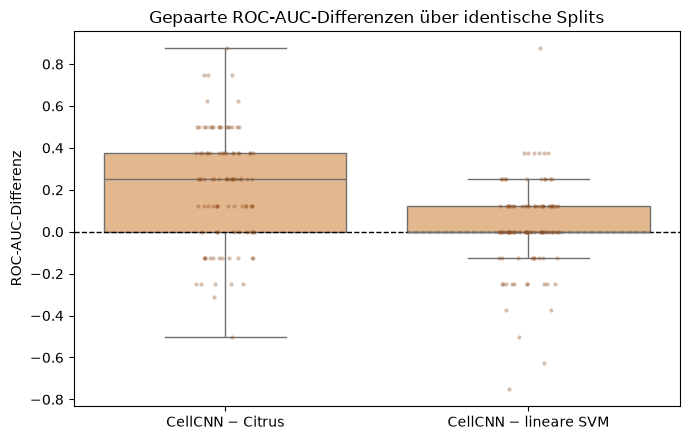

In [5]:
# Zweck: Methoden innerhalb desselben Splits paaren und so Split-Schwierigkeit herausrechnen.
roc_wide = split_metrics.pivot(index="split_id", columns="method_label", values="roc_auc")
paired_differences = pd.DataFrame(
    {
        "CellCNN − Citrus": roc_wide["CellCNN"] - roc_wide["Citrus"],
        "CellCNN − lineare SVM": (
            roc_wide["CellCNN"] - roc_wide["Lineare Single-Cell-SVM"]
        ),
    }
).reset_index()
paired_long = paired_differences.melt(
    id_vars="split_id", var_name="Vergleich", value_name="ROC-AUC-Differenz"
)
paired_summary = (
    paired_long.groupby("Vergleich")["ROC-AUC-Differenz"]
    .agg(Median="median", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75))
    .reset_index()
)
paired_differences.to_csv(TABLES_DIR / "task4_paired_roc_auc_differences.csv", index=False)
paired_summary.to_csv(TABLES_DIR / "task4_paired_roc_auc_summary.csv", index=False)
display(paired_summary.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    data=paired_long, x="Vergleich", y="ROC-AUC-Differenz",
    color="#F2B880", showfliers=False, ax=ax,
)
sns.stripplot(
    data=paired_long, x="Vergleich", y="ROC-AUC-Differenz",
    color="#8C4A1A", alpha=0.35, size=3, ax=ax,
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set(title="Gepaarte ROC-AUC-Differenzen über identische Splits", xlabel="")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task4_paired_roc_auc_differences.png", dpi=200)
plt.show()

## 6. Leistung, Interpretierbarkeit und Laufzeit

CellCNN und die lineare Single-Cell-SVM erreichen beide eine mediane ROC-AUC von
0,875, eine mediane Average Precision von 0,833 und eine mediane trapezoidale
PR-AUC von 0,792. CellCNN besitzt mit 0,750 jedoch die höhere mediane Balanced Accuracy gegenüber 0,625 für die SVM. Der direkte gepaarte ROC-AUC-Unterschied zwischen beiden hat einen Median von
0,00. Die Balanced Accuracy hängt zusätzlich von der Schwellenwertwahl ab:
CellCNN und Citrus verwenden 0,5, die SVM einen innerlich gelernten
Youden-Schwellenwert. Citrus liegt mit einer medianen ROC-AUC von 0,625, einer medianen Average
Precision von 0,500 und einer medianen trapezoidalen PR-AUC von 0,417 darunter. Gegenüber Citrus erreicht CellCNN eine mediane gepaarte ROC-AUC-Differenz von 0,25.

CellCNN liefert markerbezogene Filter und kontinuierliche Zellantworten und ist deshalb direkt mit Aufgabe 5 verknüpft. Die lineare SVM ist über ihre Markergewichte und Top-1-%-Zellscores ebenfalls interpretierbar, modelliert die prädiktive Population aber nicht als gemeinsame Repräsentation. Citrus liefert hierarchische Cluster mit Abundanzkoeffizienten; sehr kleine Koeffizienten müssen mit numerischer Toleranz als null behandelt werden.

Die vollständigen Läufe wurden mit Zwischenständen pro Split ausgeführt. CellCNN nutzte eine NVIDIA-GPU, während SVM und Citrus auf der CPU liefen; Citrus verwendet zudem ein stark parallelisiertes hierarchisches Clustering. Da die Methoden teilweise gleichzeitig und auf unterschiedlicher Hardware liefen, wären die beobachteten Gesamtzeiten kein fairer quantitativer Laufzeitvergleich. Qualitativ war die lineare SVM der einfachste Ansatz, CellCNN profitierte deutlich von der GPU-Materialisierung seiner Multi-Cell-Inputs und bei Citrus dominierte das hierarchische Clustering die Rechenzeit.

## 7. Qualitätscheck für Messtag und Instrument

Die Tabelle zeigt die Labelverteilung auf Spenderebene; beide CMV-Gruppen kommen
an jedem Messtag mit annähernd gleichen Anteilen vor. Innerhalb jedes
Trainingssplits wird ausschließlich aus Messtag bzw. Instrumentversion die
CMV+-Häufigkeit geschätzt und auf Testspender desselben Batches übertragen.
Dieser Kontrollscore ist keine vierte Hauptmethode.

Die niedrigen Kontroll-AUCs sind bei dieser kleinen, annähernd ausgeglichenen
Kohorte erklärbar: Landen überproportional viele positive Spender eines Batches
im Training, bleiben dort eher negative Spender für den komplementären Test.
Die Trainingshäufigkeit kann dann im Test in die Gegenrichtung weisen. Das ist
kein Beleg für vertauschte Labels. Ein direkter Batch-Label-Zusammenhang ist hier
nicht auffällig; technische Expressionsverschiebungen oder eine eingeschränkte
Übertragbarkeit auf neue Messtage werden dadurch nicht ausgeschlossen.
Instrumentversion und Messtag sind zudem gekoppelt und keine unabhängigen Kontrollen.


In [6]:
# Zweck: Testen, ob Messtag oder Instrument allein das Label auf neuen Spendern erklären.
data_root = PROJECT_ROOT / "NK_cell_dataset" / "NK_cell_dataset"
fcs_directory = data_root / "NK_cell_dataset" / GATE
metadata_records = []
for path in sorted(fcs_directory.glob("*.fcs")):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r"FCS file .* reported incorrect data offset.*")
        sample = fk.Sample(str(path), ignore_offset_error=True)
    metadata_records.append(
        {
            "donor_id": path.stem.removesuffix("_alive"),
            "measurement_date": sample.metadata.get("date", ""),
            "instrument": sample.metadata.get("cyt", ""),
        }
    )
technical_metadata = pd.DataFrame(metadata_records)
assert len(technical_metadata) == 20 and technical_metadata["donor_id"].is_unique
assert technical_metadata[["measurement_date", "instrument"]].ne("").all().all()
split_with_metadata = donor_splits.merge(technical_metadata, on="donor_id", validate="many_to_one")
batch_records = []
for split_id, split in split_with_metadata.groupby("split_id"):
    train = split.loc[split["outer_partition"].eq("train")]
    test = split.loc[split["outer_partition"].eq("test")]
    for variable in ("measurement_date", "instrument"):
        # Batch-Raten werden ausschließlich im Training geschätzt und dann übertragen.
        rates = train.groupby(variable)["label"].mean()
        scores = test[variable].map(rates).fillna(train["label"].mean())
        batch_records.append(
            {
                "split_id": split_id,
                "technical_variable": variable,
                "roc_auc": roc_auc_score(test["label"], scores),
            }
        )
batch_control = pd.DataFrame(batch_records)
batch_control.to_csv(TABLES_DIR / "task4_batch_control.csv", index=False)
donor_metadata = technical_metadata.merge(
    donor_splits[["donor_id", "label"]].drop_duplicates(),
    on="donor_id", validate="one_to_one",
)
batch_label_counts = pd.crosstab(donor_metadata["measurement_date"], donor_metadata["label"])
batch_label_counts = batch_label_counts.rename(columns={0: "CMV−", 1: "CMV+"})
batch_label_counts.index.name = "Messtag"
batch_label_counts.columns.name = "CMV-Status"
display(batch_label_counts)
batch_label_counts.to_csv(TABLES_DIR / "task4_batch_label_counts.csv")
batch_summary = batch_control.groupby("technical_variable")["roc_auc"].describe()
display(batch_summary.round(3))
print(
    "Der ausschließlich aus Trainings-Metadaten gebildete Kontrollscore erreicht "
    f"mediane Test-ROC-AUC {batch_summary.loc['measurement_date', '50%']:.3f} "
    f"für den Messtag und {batch_summary.loc['instrument', '50%']:.3f} "
    "für die Instrumentversion. Dies schließt technische Einflüsse auf "
    "Markerexpression und Modellleistung nicht aus."
)

CMV-Status,CMV−,CMV+
Messtag,,
01-May-2012,3,3
08-May-2012,3,2
12-Jun-2012,5,4


,count,mean,std,min,25%,50%,75%,max
technical_variable,,,,,,,,
instrument,100.0,0.376,0.126,0.125,0.25,0.375,0.5,0.5
measurement_date,100.0,0.306,0.141,0.062,0.25,0.250,0.5,0.5


Der ausschließlich aus Trainings-Metadaten gebildete Kontrollscore erreicht mediane Test-ROC-AUC 0.250 für den Messtag und 0.375 für die Instrumentversion. Dies schließt technische Einflüsse auf Markerexpression und Modellleistung nicht aus.


## Einordnung

Die 100 Monte-Carlo-Wiederholungen basieren auf denselben 20 Spendern und sind daher keine 100 unabhängigen Studien. Median und Streuung beschreiben die Sensitivität gegenüber der konkreten Train-Test-Aufteilung. Inhaltliche Schlussfolgerungen müssen die kleine Zahl unabhängiger Spender ausdrücklich berücksichtigen.

Bei Citrus gelten nur glmnet-Koeffizienten mit `abs(coefficient) > 1e-10` als
wirksam. Diese Regel gilt einheitlich für Clusterzahlen und exportierte Profile. Die offizielle Citrus-Ausgabe kann formal nicht-null Koeffizienten in der Größenordnung `1e-15` liefern, obwohl daraus konstante Spendervorhersagen von 0,5 entstehen.